In [2]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/dsce/vpal/VPAL/Personality"
file_name = "PersonalityScoresVpal2.csv"

Mounted at /content/drive


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv(os.path.join(base_path, file_name))
df = df.dropna(subset=["ACmotivation", "ACmetacog"])
x = df["ACmotivation"].to_numpy()
y = df["ACmetacog"].to_numpy()
n = len(df)
n

76

I use the VPAL PersonalityScoresVpal2 dataset and focus on two continuous variables: ACmotivation (academic motivation) and ACmetacog (metacognitive control). After dropping rows with missing values in either column, I have 76 learners in my sample. My core question is: “Do learners who report higher academic motivation also report stronger metacognitive control?”



From the histogram of ACmotivation, the scores are roughly bell shaped, with most learners sitting in the middle and no extreme outliers.

The mean ACmotivation is 15.34 and the median is 15.5. Because the distribution looks fairly symmetric and the mean and median are very close, I treat the mean as the main typical value here, since it summarizes the overall level of motivation across the group.


The standard deviation of ACmotivation is about 2.28. I read this as: on average, a learner’s motivation score is a bit over 2 points away from the mean, so motivation varies a fair amount across students but it’s not wildly scattered.



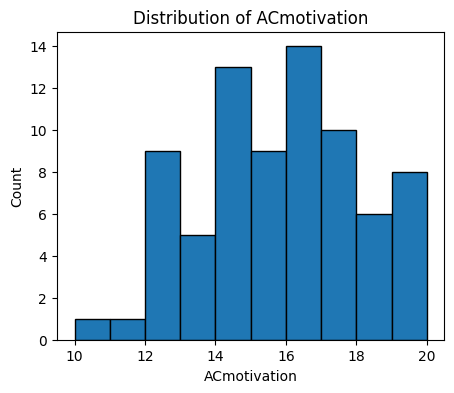

(np.float64(15.342105263157896),
 np.float64(15.5),
 np.float64(2.2835798304647166))

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(x, bins=10, edgecolor="black")
ax.set_title("Distribution of ACmotivation")
ax.set_xlabel("ACmotivation")
ax.set_ylabel("Count")
plt.show()

mean_x = x.mean()
median_x = np.median(x)
sd_x = x.std(ddof=1)
mean_x, median_x, sd_x

The standard error of the mean for ACmotivation is about 0.26, and the 95% confidence interval for the true population mean runs from 14.83 to 15.86.

Based on this sample, I am reasonably confident that the true average ACmotivation for similar learners is somewhere between about 14.8 and 15.9.

In [8]:
se_x = sd_x / np.sqrt(n)
ci_low = mean_x - 1.96 * se_x
ci_high = mean_x + 1.96 * se_x
se_x, ci_low, ci_high

(np.float64(0.261944571329038),
 np.float64(14.828693903352981),
 np.float64(15.85551662296281))

In the scatter plot of ACmotivation vs ACmetacog the points form a loose upward cloud: higher motivation tends to go along with higher metacognitive scores, and there is no obvious curve or weird outliers. Because of this roughly linear pattern, I use Pearson’s r as the correlation measure.

The Pearson correlation between ACmotivation and ACmetacog is r ≈ 0.56 with p ≈ 1.6 × 10⁻⁷, which I interpret as a moderate positive relationship that is statistically significant. In other words in this sample, more motivated learners tend to report stronger metacognitive control, but this is still a correlation and does not prove that motivation causes better metacognition.

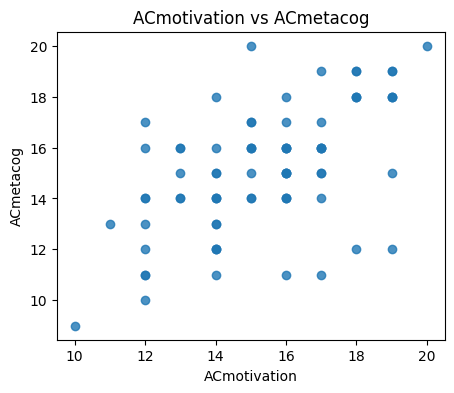

(np.float64(0.5586103347697082), np.float64(1.5726913197015538e-07))

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, alpha=0.8)
ax.set_title("ACmotivation vs ACmetacog")
ax.set_xlabel("ACmotivation")
ax.set_ylabel("ACmetacog")
plt.show()

pearson_r, p_val = stats.pearsonr(x, y)
pearson_r, p_val

Imagine I am helping design study skills support for this group.

Type I error (false alarm): I might conclude that motivation and metacognition are tightly linked and design a special program only for “high motivation, high metacog” students, when in reality the relationship is just noise. That would waste effort on a targeted intervention that does not actually match how learners behave.

Type II error (missed signal): I might decide there is no useful relationship and ignore it, even though in reality more motivated learners really do have stronger metacognitive skills. In that case I would miss a chance to tailor support or advanced materials for students who could benefit from them.

Verdict: For this assignment, I see Type I error as more dangerous, because building features around a pattern that isn’t real would send my design in the wrong direction and burn limited time, while missing a moderate real effect is less costly at this early exploratory stage.